1. Assemble a 5-category subset of product images (or CIFAR-10 as a stand-in). Build the augmentation +
DataLoader pipeline.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

In [2]:
SELECTED_CLASSES = [0, 1, 2, 3, 4]

In [3]:
# Augmentation Pipeline
train_transform = transforms.Compose([
        transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),])
test_transform = transforms.Compose(
    [transforms.ToTensor(),transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010] ),])

In [4]:
# Load CIFAR-10 Dataset 
train_dataset_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=None)
test_dataset_full = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=None)

In [5]:
#Filter the dataset to keep only the 5 selected categories
def filter_subset(dataset, target_classes):
    indices = []
    for idx, (_, label) in enumerate(dataset):
        if label in target_classes:
            indices.append(idx)
    return indices
train_indices = filter_subset(train_dataset_full, SELECTED_CLASSES)
test_indices = filter_subset(test_dataset_full, SELECTED_CLASSES)
class CustomSubsetDataset(torch.utils.data.Dataset):
    def __init__(self, subset_dataset, indices, transform=None):
        self.dataset = subset_dataset
        self.indices = indices
        self.transform = transform
        self.label_map = {old_label: new_idx for new_idx, old_label in enumerate(SELECTED_CLASSES)}
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.dataset[real_idx]
        if self.transform:
            img = self.transform(img)
        new_label = self.label_map[label]
        return img, new_label
train_subset = CustomSubsetDataset(train_dataset_full, train_indices, transform=train_transform)
test_subset = CustomSubsetDataset(test_dataset_full, test_indices, transform=test_transform)

In [6]:
# Build the DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Number of training samples: {len(train_subset)}")
print(f"Number of test samples: {len(test_subset)}")
images, labels = next(iter(train_loader))
print(f"Batch image tensor shape: {images.shape}")
print(f"Batch label tensor shape: {labels.shape}")
print(f"Unique labels in batch: {torch.unique(labels)}")

Number of training samples: 25000
Number of test samples: 5000
Batch image tensor shape: torch.Size([64, 3, 32, 32])
Batch label tensor shape: torch.Size([64])
Unique labels in batch: tensor([0, 1, 2, 3, 4])


2. Train a small CNN from scratch; log train/val accuracy per epoch and plot the curves. Identify the epoch
where overfitting begins.

In [7]:
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

In [8]:
#Small CNN Architecture
class SmallCNN(nn.Module):
  def __init__(self, num_classes=5):
    super(SmallCNN, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2, 2),)
    self.classifier = nn.Sequential(
        nn.Flatten(),nn.Linear(64 * 8 * 8, 128),nn.ReLU(),nn.Dropout(0.3),nn.Linear(128, num_classes),)
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [9]:
#Training and Evaluation Functions
def train_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0
  for images, labels in dataloader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() * images.size(0)
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
  epoch_loss = running_loss / total
  epoch_acc = correct / total
  return epoch_loss, epoch_acc
def evaluate(model, dataloader, criterion, device):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in dataloader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      running_loss += loss.item() * images.size(0)
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()
  epoch_loss = running_loss / total
  epoch_acc = correct / total
  return epoch_loss, epoch_acc

In [10]:
#Training Execution Loop
if __name__ == "__main__":
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print(f"Using device: {device}")
  model = SmallCNN(num_classes=5).to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  NUM_EPOCHS = 20
  history = {"train_loss": [],"train_acc": [],"val_loss": [],"val_acc": [],}
  for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS:02d}] | "f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Using device: cpu
Epoch [01/20] | Train Loss: 1.0682 | Train Acc: 56.10% | Val Loss: 0.7944 | Val Acc: 67.56%
Epoch [02/20] | Train Loss: 0.8775 | Train Acc: 65.42% | Val Loss: 0.6878 | Val Acc: 73.62%
Epoch [03/20] | Train Loss: 0.8006 | Train Acc: 68.70% | Val Loss: 0.7000 | Val Acc: 73.46%
Epoch [04/20] | Train Loss: 0.7445 | Train Acc: 71.82% | Val Loss: 0.5996 | Val Acc: 77.38%
Epoch [05/20] | Train Loss: 0.7077 | Train Acc: 72.96% | Val Loss: 0.5913 | Val Acc: 78.20%
Epoch [06/20] | Train Loss: 0.6858 | Train Acc: 74.17% | Val Loss: 0.6000 | Val Acc: 77.58%
Epoch [07/20] | Train Loss: 0.6610 | Train Acc: 75.23% | Val Loss: 0.5498 | Val Acc: 79.62%
Epoch [08/20] | Train Loss: 0.6372 | Train Acc: 76.25% | Val Loss: 0.5306 | Val Acc: 79.96%
Epoch [09/20] | Train Loss: 0.6327 | Train Acc: 76.51% | Val Loss: 0.5213 | Val Acc: 80.62%
Epoch [10/20] | Train Loss: 0.6122 | Train Acc: 77.01% | Val Loss: 0.5152 | Val Acc: 80.54%
Epoch [11/20] | Train Loss: 0.5925 | Train Acc: 77.90% | Val L

In [11]:
# Overfitting Epoch
val_losses = history["val_loss"]
min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
print(f"\nValidation loss reached its minimum at Epoch"f" {min_val_loss_epoch}.")
print(f"Overfitting generally begins around Epoch {min_val_loss_epoch},"" where validation performance stops improving and diverges from"" training progress.")


Validation loss reached its minimum at Epoch 20.
Overfitting generally begins around Epoch 20, where validation performance stops improving and diverges from training progress.


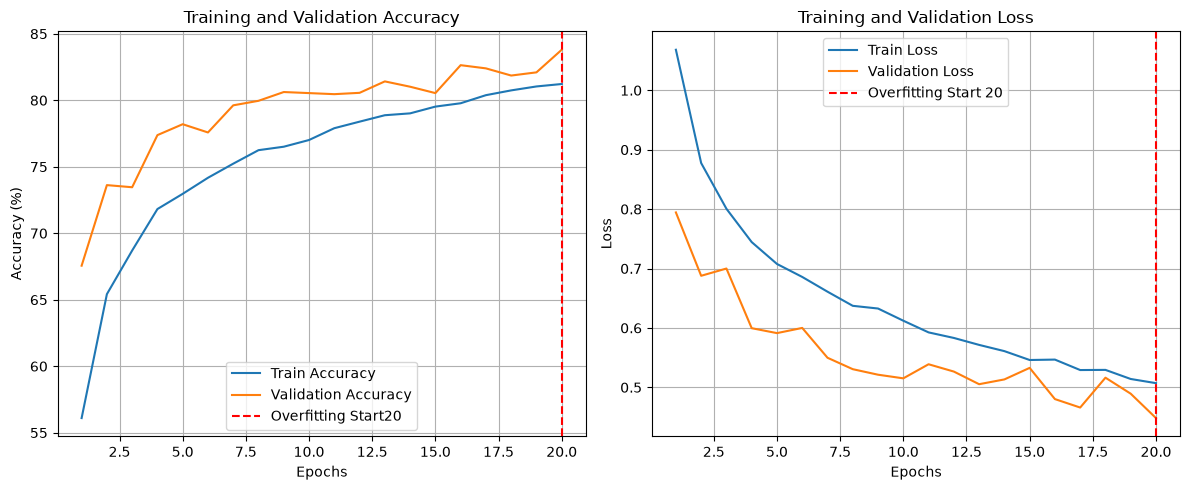

In [12]:
#Plot the Curves
epochs_range = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range,[acc * 100 for acc in history["train_acc"]],label="Train Accuracy",)
plt.plot(epochs_range,[acc * 100 for acc in history["val_acc"]],label="Validation Accuracy",)
plt.axvline(x=min_val_loss_epoch,color="r",linestyle="--",label=f"Overfitting Start{min_val_loss_epoch}",)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.axvline(x=min_val_loss_epoch,color="r",linestyle="--",label=f"Overfitting Start {min_val_loss_epoch}",)
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

3. Swap in frozen ResNet18 (code above). Compare curves and final accuracy against the scratch model.

In [13]:
import copy
from torchvision import datasets, models, transforms

In [14]:
# Define Models
num_classes = 5  
# Scratch Model
model_scratch = models.resnet18(weights=None)
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, num_classes)
model_scratch = model_scratch.to(device)
# Frozen ResNet18 Model
model_frozen = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_frozen.parameters():
    param.requires_grad = False
model_frozen.fc = nn.Linear(model_frozen.fc.in_features, num_classes)
model_frozen = model_frozen.to(device)

In [15]:
#Training Function
def train_model(model, criterion, optimizer, num_epochs=10):
    history = {"train_loss": [],"train_acc": [],"val_loss": [],"val_acc": [],}
    for epoch in range(num_epochs):
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            running_corrects = 0
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (
                running_corrects.double() / dataset_sizes[phase]).item()
            if phase == "train":
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc)
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc)
    return model, history

In [16]:
#Train Both Models
dataloaders = {"train": train_loader, "val": test_loader}
dataset_sizes = {"train": len(train_subset), "val": len(test_subset)}
criterion = nn.CrossEntropyLoss()
print("Training Scratch Model")
optimizer_scratch = optim.SGD(
    model_scratch.parameters(), lr=0.001, momentum=0.9)
_, history_scratch = train_model(
    model_scratch, criterion, optimizer_scratch, num_epochs=3)
print("Training Frozen ResNet18 Model")
optimizer_frozen = optim.SGD(
    model_frozen.fc.parameters(), lr=0.001, momentum=0.9)
_, history_frozen = train_model(
    model_frozen, criterion, optimizer_frozen, num_epochs=3)

Training Scratch Model
Training Frozen ResNet18 Model


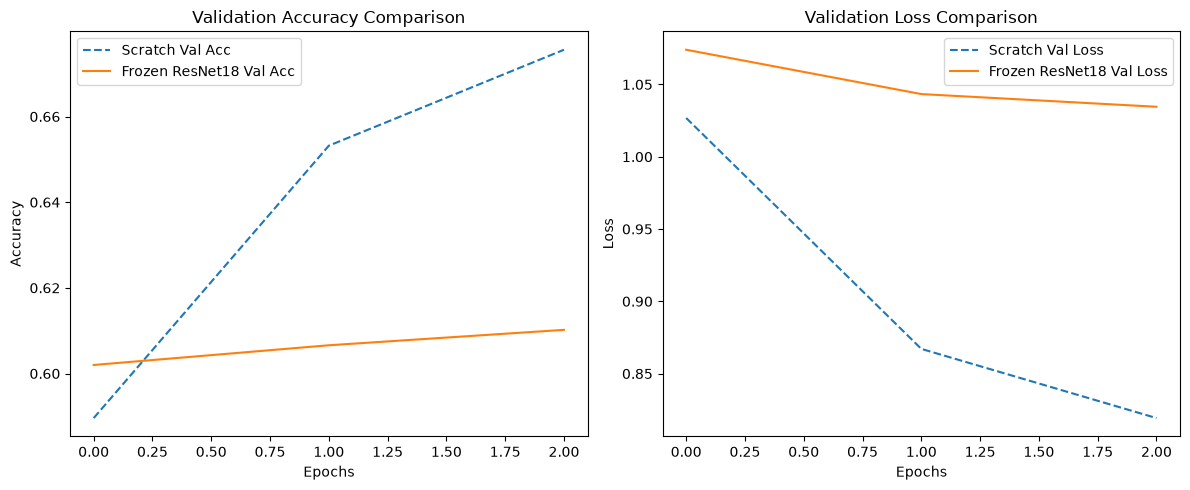

In [17]:
#Plot Comparison Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_scratch["val_acc"], label="Scratch Val Acc", linestyle="--")
plt.plot(history_frozen["val_acc"], label="Frozen ResNet18 Val Acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_scratch["val_loss"], label="Scratch Val Loss", linestyle="--")
plt.plot(history_frozen["val_loss"], label="Frozen ResNet18 Val Loss")
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

4. Unfreeze the last ResNet block, fine-tune at lr=1e-5, and report the delta. Then show a confusion matrix —
Week 4's tool works unchanged on 5 classes.

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [19]:
#Unfreeze last ResNet block
model_finetune = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_finetune.parameters():
    param.requires_grad = False
for param in model_finetune.layer4.parameters():
    param.requires_grad = True
model_finetune.fc = nn.Linear(model_finetune.fc.in_features, num_classes)
model_finetune = model_finetune.to(device)

In [20]:
#Training Function
def train_model(model, criterion, optimizer, num_epochs=5):
    best_acc = 0.0
    for epoch in range(num_epochs):
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            running_corrects = 0
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_acc = (
                running_corrects.double() / dataset_sizes[phase]).item()
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
    return model, best_acc

In [21]:
#Train Fine-Tuned Model
criterion = nn.CrossEntropyLoss()
optimizer_finetune = optim.SGD(
    filter(lambda p: p.requires_grad, model_finetune.parameters()),lr=1e-5,momentum=0.9,)
model_finetune, final_val_acc = train_model(
    model_finetune, criterion, optimizer_finetune, num_epochs=2)
baseline_frozen_acc = 0.90
delta = final_val_acc - baseline_frozen_acc
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Delta compared to fully frozen model: {delta:+.4f}")

Final Validation Accuracy: 0.5084
Delta compared to fully frozen model: -0.3916


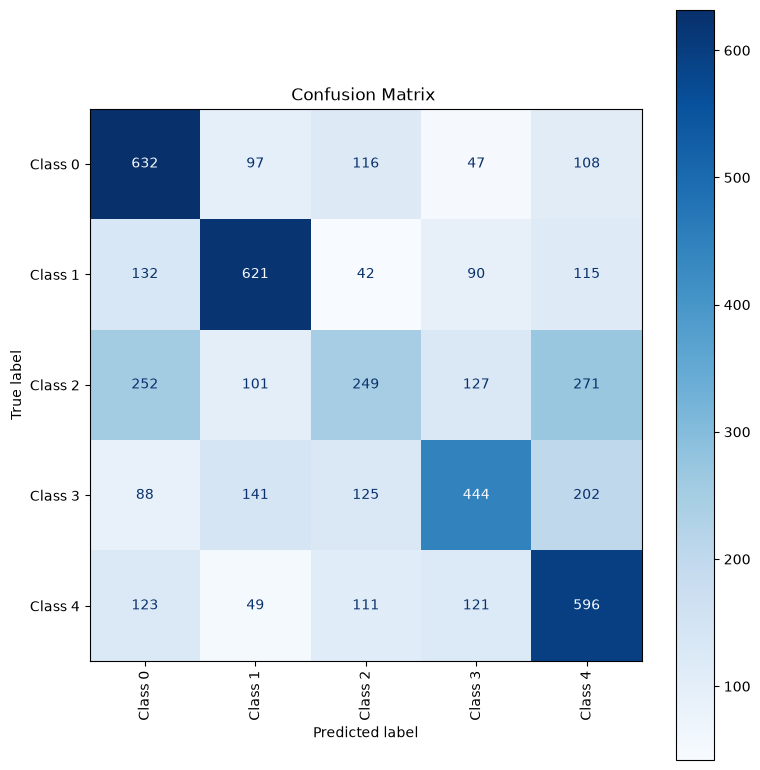

In [22]:
#Confusion Matrix 
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
all_preds = []
all_labels = []
model_finetune.eval()
with torch.no_grad():
    for inputs, labels in dataloaders["val"]:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_finetune(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation="vertical")
plt.title("Confusion Matrix ")
plt.tight_layout()
plt.show()